In [ ]:
#import shutil
#shutil.rmtree('/content/Thesis', ignore_errors=True)

## YOLOv5s Android Real-Time Detection

Import packages

In [ ]:
import os
import sys
import subprocess
import shutil
from pathlib import Path
import yaml
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Check system requirements


In [ ]:
def check_system_requirements():
    python_version = sys.version_info
    print(f"Python version: {python_version.major}.{python_version.minor}.{python_version.micro}")

    if python_version.major != 3 or python_version.minor < 8:
        print("Warning: Python 3.8+ is recommended")

    try:
        import torch
        print(f"PyTorch version: {torch.__version__}")
        print(f"CUDA available: {torch.cuda.is_available()}")
        if torch.cuda.is_available():
            print(f"CUDA version: {torch.version.cuda}")
            print(f"GPU count: {torch.cuda.device_count()}")
            print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    except ImportError:
        print("PyTorch not installed")

    import shutil
    total, used, free = shutil.disk_usage(".")
    print(f"Available disk space: {free // (2**30)} GB")

    if free < 5 * (2**30):  # Less than 5GB
        print("Warning: Low disk space. Training requires at least 5GB free space")

check_system_requirements()

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("Using CPU")

Python version: 3.12.11
PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
Current GPU: Tesla T4
Available disk space: 73 GB
Using GPU: Tesla T4


Install packages

In [ ]:
def install_dependencies():
    packages = [
        "ultralytics",
        "opencv-python",
        "matplotlib",
        "seaborn",
        "pillow",
        "pyyaml",
        "tqdm",
        "tensorboard",
        "onnx",
        "onnxruntime",
        "tensorflow",
        "tf2onnx"
    ]

    for package in packages:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"Installed {package}")
        except subprocess.CalledProcessError:
            print(f"Failed to install {package}")

Clone YOLOv5 repository

In [ ]:
def clone_yolov5_repo():
    if not os.path.exists("yolov5"):
        try:
            subprocess.check_call(["git", "clone", "https://github.com/ultralytics/yolov5.git"])
            print("YOLOv5 repository cloned successfully")
        except subprocess.CalledProcessError:
            print("Failed to clone YOLOv5 repository")
            return False
    else:
        print("YOLOv5 repository already exists")

    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "yolov5/requirements.txt"])
        print("YOLOv5 requirements installed")
    except subprocess.CalledProcessError:
        print("Failed to install YOLOv5 requirements")
        return False

    return True

install_dependencies()
clone_success = clone_yolov5_repo()

if not clone_success:
    print("Failed to set up YOLOv5. Please check your internet connection and try again.")

Installed ultralytics
Installed opencv-python
Installed matplotlib
Installed seaborn
Installed pillow
Installed pyyaml
Installed tqdm
Installed tensorboard
Installed onnx
Installed onnxruntime
Installed tensorflow
Installed tf2onnx
YOLOv5 repository cloned successfully
YOLOv5 requirements installed


# Setup Folder Structure

In [ ]:
def create_folder_structure():
    folders = [
        "Thesis/dataset/images/train",
        "Thesis/dataset/images/val",
        "Thesis/dataset/labels/train",
        "Thesis/dataset/labels/val",
        "Thesis/input",
        "Thesis/output",
        "Thesis/metrics",
        "Thesis/models"
    ]

    for folder in folders:
        Path(folder).mkdir(parents=True, exist_ok=True)
        print(f"Created {folder}")

    print("Folder structure created successfully")

Create data.yaml file for YOLOv5 training

In [ ]:
def create_dataset_yaml():
    dataset_config = {
        'train': 'Thesis/dataset/images/train',
        'val': 'Thesis/dataset/images/val',
        'nc': 2,  # Number of classes
        'names': ['nsfw', 'gore']
    }

    with open('Thesis/dataset/data.yaml', 'w') as f:
        yaml.dump(dataset_config, f, default_flow_style=False)

    print("Dataset configuration file created")
    return 'Thesis/dataset/data.yaml'

Create a training configuration file for easy modification

In [ ]:
def create_training_config():
    config = {
        'model': {
            'architecture': 'yolov5s',
            'input_size': 640,
            'num_classes': 2,
            'class_names': ['nsfw', 'gore']
        },
        'training': {
            'batch_size': 16,
            'epochs': 100,
            'learning_rate': 0.01,
            'momentum': 0.937,
            'weight_decay': 0.0005,
            'patience': 15
        },
        'export': {
            'formats': ['onnx', 'tflite'],
            'optimize_for_mobile': True,
            'quantization': True
        }
    }

    with open('Thesis/training_config.yaml', 'w') as f:
        yaml.dump(config, f, default_flow_style=False)

    print("Training configuration saved to Thesis/training_config.yaml")

In [ ]:
create_folder_structure()
data_yaml_path = create_dataset_yaml()
create_training_config()

Created Thesis/dataset/images/train
Created Thesis/dataset/images/val
Created Thesis/dataset/labels/train
Created Thesis/dataset/labels/val
Created Thesis/input
Created Thesis/output
Created Thesis/metrics
Created Thesis/models
Folder structure created successfully
Dataset configuration file created
Training configuration saved to Thesis/training_config.yaml


# Dataset Preparation Utilities

In [ ]:
def validate_dataset_structure():
    required_paths = [
        'Thesis/dataset/images/train',
        'Thesis/dataset/images/val',
        'Thesis/dataset/labels/train',
        'Thesis/dataset/labels/val',
        'Thesis/dataset/data.yaml'
    ]

    for path in required_paths:
        if not os.path.exists(path):
            print(f"Missing: {path}")
            return False
        else:
            print(f"Found: {path}")

    train_images = len([f for f in os.listdir('Thesis/dataset/images/train') if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    val_images = len([f for f in os.listdir('Thesis/dataset/images/val') if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    train_labels = len([f for f in os.listdir('Thesis/dataset/labels/train') if f.endswith('.txt')])
    val_labels = len([f for f in os.listdir('Thesis/dataset/labels/val') if f.endswith('.txt')])

    print(f"Training images: {train_images}, Training labels: {train_labels}")
    print(f"Validation images: {val_images}, Validation labels: {val_labels}")

    if train_images == 0 or val_images == 0:
        print("Warning: No images found in dataset folders")
        print("Will use preexisting YOLOv5 dataset for training")
        return False

    return True

In [ ]:
def setup_preexisting_dataset():
    available_datasets = {
        'coco128': {
            'url': 'https://ultralytics.com/assets/coco128.zip',
            'nc': 80,
            'description': 'COCO dataset subset (128 images, 80 classes)'
        },
        'voc': {
            'yaml': 'VOC.yaml',
            'nc': 20,
            'description': 'Pascal VOC dataset (20 classes)'
        },
        'Objects365': {
            'yaml': 'Objects365.yaml',
            'nc': 365,
            'description': 'Objects365 dataset (365 classes)'
        }
    }

    selected_dataset = 'coco128'
    print(f"Selected dataset: {selected_dataset} - {available_datasets[selected_dataset]['description']}")

    current_dir = os.getcwd()

    if selected_dataset == 'coco128':
        import zipfile
        import urllib.request
        from urllib.parse import urlparse

        dataset_url = available_datasets[selected_dataset]['url']
        dataset_zip = 'coco128.zip'

        print(f"Downloading {selected_dataset} dataset...")
        try:
            urllib.request.urlretrieve(dataset_url, dataset_zip)
            print(f"Downloaded {dataset_zip}")

            # Extract directly into Thesis/dataset structure
            with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
                # Extract all files first to a temporary location
                zip_ref.extractall('temp_coco128')
            print("Extracted dataset to temporary location")

            # Move images to dataset folder
            temp_images_path = 'temp_coco128/coco128/images/train2017'
            temp_labels_path = 'temp_coco128/coco128/labels/train2017'

            if os.path.exists(temp_images_path):
                # Copy images to both train and val folders
                for image_file in os.listdir(temp_images_path):
                    if image_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        shutil.copy2(os.path.join(temp_images_path, image_file),
                                   'Thesis/dataset/images/train/')
                        shutil.copy2(os.path.join(temp_images_path, image_file),
                                   'Thesis/dataset/images/val/')
                print("Copied images to dataset folders")

            if os.path.exists(temp_labels_path):
                # Copy labels to both train and val folders
                for label_file in os.listdir(temp_labels_path):
                    if label_file.endswith('.txt'):
                        shutil.copy2(os.path.join(temp_labels_path, label_file),
                                   'Thesis/dataset/labels/train/')
                        shutil.copy2(os.path.join(temp_labels_path, label_file),
                                   'Thesis/dataset/labels/val/')
                print("Copied labels to dataset folders")
            # Clean up temporary files
            shutil.rmtree('temp_coco128')
            os.remove(dataset_zip)

            # Update data.yaml for COCO128
            coco128_config = {
                'train': os.path.join(current_dir, 'Thesis/dataset/images/train'),
                'val': os.path.join(current_dir, 'Thesis/dataset/images/val'),
                'nc': 80,
                'names': [
                    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
                    'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat',
                    'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
                    'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
                    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
                    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
                    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
                    'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop',
                    'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
                    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
                ]
            }

            with open('Thesis/dataset/data.yaml', 'w') as f:
                yaml.dump(coco128_config, f, default_flow_style=False)

            # Update training config for COCO128
            config = {
                'model': {
                    'architecture': 'yolov5s',
                    'input_size': 640,
                    'num_classes': 80,
                    'class_names': coco128_config['names']
                },
                'training': {
                    'batch_size': 16,
                    'epochs': 100,
                    'learning_rate': 0.01,
                    'momentum': 0.937,
                    'weight_decay': 0.0005,
                    'patience': 15
                },
                'export': {
                    'formats': ['onnx', 'tflite'],
                    'optimize_for_mobile': True,
                    'quantization': True
                }
            }

            with open('Thesis/training_config.yaml', 'w') as f:
                yaml.dump(config, f, default_flow_style=False)
            print("Created COCO128 dataset configuration and updated training config")
            return 'Thesis/dataset/data.yaml'

        except Exception as e:
            print(f"Failed to download COCO128: {e}")
            return None

    else:
        selected_config = available_datasets[selected_dataset]

        builtin_config = {
            'train': f'../{selected_config["yaml"]}',  # Will use YOLOv5's built-in config
            'val': f'../{selected_config["yaml"]}',
            'nc': selected_config['nc'],
            'names': [f'class_{i}' for i in range(selected_config['nc'])]  # Generic class names
        }

        with open('Thesis/dataset/data.yaml', 'w') as f:
            yaml.dump(builtin_config, f, default_flow_style=False)

        print(f"Configured to use {selected_dataset} dataset")
        return 'Thesis/dataset/data.yaml'

In [ ]:
# Validate dataset structure and setup preexisting dataset if needed
dataset_valid = validate_dataset_structure()

if not dataset_valid:
    print("Setting up preexisting dataset for demonstration...")
    data_yaml_path = setup_preexisting_dataset()
    if data_yaml_path:
        print("Preexisting dataset setup completed")
    else:
        print("Failed to setup preexisting dataset")

Found: Thesis/dataset/images/train
Found: Thesis/dataset/images/val
Found: Thesis/dataset/labels/train
Found: Thesis/dataset/labels/val
Found: Thesis/dataset/data.yaml
Training images: 0, Training labels: 0
Validation images: 0, Validation labels: 0
Will use preexisting YOLOv5 dataset for training
Setting up preexisting dataset for demonstration...
Selected dataset: coco128 - COCO dataset subset (128 images, 80 classes)
Downloaded coco128.zip
Extracted dataset to temporary location
Copied images to dataset folders
Copied labels to dataset folders
Created COCO128 dataset configuration and updated training config
Preexisting dataset setup completed


# Training Configuration Class

In [ ]:
class YOLOv5Trainer:
    def __init__(self, data_yaml_path, use_preexisting=False):
        self.data_yaml_path = data_yaml_path
        self.use_preexisting = use_preexisting
        self.model_size = 'yolov5s'
        self.img_size = 640
        self.batch_size = 16
        self.epochs = 100 if not use_preexisting else 50  # Fewer epochs for preexisting datasets
        self.project = 'Thesis/training_results'
        self.name = 'yolov5s_training'
        self.patience = 15

    def train_model(self):
        """Train YOLOv5s model"""
        if self.use_preexisting:
            print("Starting YOLOv5s training with preexisting dataset...")
        else:
            print("Starting YOLOv5s training with custom dataset...")

        original_dir = os.getcwd()
        os.chdir('yolov5')

        if self.use_preexisting and 'coco128' in self.data_yaml_path:
            data_path = '../coco128.yaml'  # Use the extracted COCO128 dataset
            # Create coco128.yaml in the parent directory
            coco128_yaml = {
                'train': 'coco128/images/train2017',
                'val': 'coco128/images/train2017',
                'nc': 80,
                'names': [
                    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
                    'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat',
                    'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
                    'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
                    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
                    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
                    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
                    'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop',
                    'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
                    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
                ]
            }
            with open('../coco128.yaml', 'w') as f:
                yaml.dump(coco128_yaml, f, default_flow_style=False)
        else:
            data_path = f'../{self.data_yaml_path}'

        train_cmd = [
            sys.executable, 'train.py',
            '--data', data_path,
            '--weights', f'{self.model_size}.pt',
            '--img', str(self.img_size),
            '--batch-size', str(self.batch_size),
            '--epochs', str(self.epochs),
            '--project', f'../{self.project}',
            '--name', self.name,
            '--save-period', '10',  # Save checkpoint every 10 epochs
            '--cache',
            '--patience', str(self.patience),
            '--hyp', 'hyp.scratch-low.yaml'
        ]

        if self.use_preexisting:
            train_cmd.extend(['--patience', '20'])  # Early stopping

        try:
            print(f"Training command: {' '.join(train_cmd)}")
            result = subprocess.run(train_cmd, capture_output=True, text=True)

            if result.returncode == 0:
                print("Training completed successfully")
                # Filter out the line with the check mark
                filtered_output = "\n".join([line for line in result.stdout.splitlines() if '✅' not in line])
                print("Training output:", filtered_output[-1000:])  # Show last 1000 chars
            else:
                print("Training failed")
                print("Error:", result.stderr)
                return False

        except Exception as e:
            print(f"Training failed with exception: {e}")
            return False
        finally:
            os.chdir(original_dir)  # Return to original directory

        return True

    def get_best_weights_path(self):
        """Get path to the best trained weights"""
        weights_path = f'{self.project}/{self.name}/weights/best.pt'
        if os.path.exists(weights_path):
            return weights_path
        else:
            print(f"Best weights not found at {weights_path}")
            return None

In [ ]:
# Initialize trainer
use_preexisting = not dataset_valid  # Use preexisting if custom dataset validation failed
trainer = YOLOv5Trainer(data_yaml_path, use_preexisting=use_preexisting)

print(f"Trainer initialized with:")
print(f"  - Dataset: {data_yaml_path}")
print(f"  - Using preexisting dataset: {use_preexisting}")
print(f"  - Model: {trainer.model_size}")
print(f"  - Epochs: {trainer.epochs}")
print(f"  - Batch size: {trainer.batch_size}")

Trainer initialized with:
  - Dataset: Thesis/dataset/data.yaml
  - Using preexisting dataset: True
  - Model: yolov5s
  - Epochs: 50
  - Batch size: 16


In [ ]:
def debug_dataset_paths():

    # Check current working directory
    print(f"Current working directory: {os.getcwd()}")

    # Check if YOLOv5 directory exists
    if os.path.exists('yolov5'):
        print("YOLOv5 directory found")
    else:
        print("YOLOv5 directory not found")
        return

    # Check data.yaml file
    print(f"\nChecking data.yaml file: {data_yaml_path}")
    if os.path.exists(data_yaml_path):
        with open(data_yaml_path, 'r') as f:
            config = yaml.safe_load(f)
        print("Data.yaml found with config:")
        for key, value in config.items():
            print(f"   {key}: {value}")

        # Check if paths in data.yaml exist
        print(f"\nVerifying dataset paths:")

        train_path = config.get('train', '')
        val_path = config.get('val', '')

        # Check from current directory
        print(f"From current directory:")
        if os.path.exists(train_path):
            train_files = len([f for f in os.listdir(train_path)
                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"Train path: {train_path} ({train_files} images)")
        else:
            print(f"Train path not found: {train_path}")

        if os.path.exists(val_path):
            val_files = len([f for f in os.listdir(val_path)
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"Val path: {val_path} ({val_files} images)")
        else:
            print(f"Val path not found: {val_path}")

        # Check from YOLOv5 directory (how training script will see it)
        print(f"\nFrom YOLOv5 directory (training perspective):")
        original_dir = os.getcwd()
        os.chdir('yolov5')

        # Adjust paths for YOLOv5 perspective
        yolo_train_path = f"../{train_path}" if not train_path.startswith('../') else train_path
        yolo_val_path = f"../{val_path}" if not val_path.startswith('../') else val_path

        if os.path.exists(yolo_train_path):
            train_files = len([f for f in os.listdir(yolo_train_path)
                              if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"Train path: {yolo_train_path} ({train_files} images)")
        else:
            print(f"Train path not found: {yolo_train_path}")

        if os.path.exists(yolo_val_path):
            val_files = len([f for f in os.listdir(yolo_val_path)
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"Val path: {yolo_val_path} ({val_files} images)")
        else:
            print(f"Val path not found: {yolo_val_path}")

        os.chdir(original_dir)

    else:
        print(f"Data.yaml not found: {data_yaml_path}")

    # If using COCO128, check its specific structure
    if use_preexisting and 'coco128' in str(data_yaml_path):
        print(f"\nCOCO128 specific checks:")
        coco128_base = 'coco128'
        if os.path.exists(coco128_base):
            print(f"COCO128 base directory exists")

            # Check subdirectories
            expected_dirs = ['images/train2017', 'labels/train2017']
            for expected_dir in expected_dirs:
                full_path = os.path.join(coco128_base, expected_dir)
                if os.path.exists(full_path):
                    file_count = len(os.listdir(full_path))
                    print(f"{expected_dir}: {file_count} files")
                else:
                    print(f"Missing: {expected_dir}")
        else:
            print(f"COCO128 base directory not found")

Debug Dataset Paths

In [ ]:
debug_dataset_paths()

Current working directory: /content
YOLOv5 directory found

Checking data.yaml file: Thesis/dataset/data.yaml
Data.yaml found with config:
   names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'to

# Start Training

In [ ]:
training_success = trainer.train_model()

if training_success:
    print("Training completed successfully!")
    best_weights = trainer.get_best_weights_path()
    if best_weights:
        print(f"Best weights saved at: {best_weights}")
    else:
        print("Could not locate best weights file")
else:
    print("Training failed. Please check the error messages above.")

Starting YOLOv5s training with preexisting dataset...
Training command: /usr/bin/python3 train.py --data ../Thesis/dataset/data.yaml --weights yolov5s.pt --img 640 --batch-size 16 --epochs 50 --project ../Thesis/training_results --name yolov5s_training --save-period 10 --cache --patience 15 --hyp hyp.scratch-low.yaml --patience 20
Training completed successfully
Training output: 
Training completed successfully!
Best weights saved at: Thesis/training_results/yolov5s_training/weights/best.pt


# Model Validation

In [ ]:
def validate_model(weights_path, data_yaml_path):
    original_dir = os.getcwd()
    os.chdir('yolov5')

    val_cmd = [
        sys.executable, 'val.py',
        '--data', f'../{data_yaml_path}',
        '--weights', f'../{weights_path}',
        '--img', '640',
        '--batch-size', '16',
        '--project', '../Thesis/metrics',
        '--name', 'validation_results',
        '--save-txt',
        '--save-conf'
    ]

    try:
        print(f"Validation command: {' '.join(val_cmd)}")
        result = subprocess.run(val_cmd, capture_output=True, text=True)

        if result.returncode == 0:
            print("Validation completed successfully")
            print("Validation output:", result.stdout)
        else:
            print("Validation failed")
            print("Error:", result.stderr)
            return False

    except Exception as e:
        print(f"Validation failed with exception: {e}")
        return False
    finally:
        os.chdir(original_dir)

    return True

In [ ]:
# Validate the model if training was successful
if training_success and best_weights:
    print("Starting model validation...")
    validation_success = validate_model(best_weights, data_yaml_path)

    if validation_success:
        print("Model validation completed successfully")
    else:
        print("Validation failed, but continuing with export...")
else:
    print("Skipping validation due to training failure")


Starting model validation...
Validation command: /usr/bin/python3 val.py --data ../Thesis/dataset/data.yaml --weights ../Thesis/training_results/yolov5s_training/weights/best.pt --img 640 --batch-size 16 --project ../Thesis/metrics --name validation_results --save-txt --save-conf
Validation completed successfully
Validation output: 
Model validation completed successfully


# Model Export Class

In [ ]:
class ModelExporter:
    def __init__(self, weights_path):
        self.weights_path = weights_path
        self.models_dir = 'Thesis/models'

    def export_to_onnx(self):
        original_dir = os.getcwd()
        os.chdir('yolov5')

        # Get the absolute path to the weights file
        weights_abs_path = os.path.abspath(f'../{self.weights_path}')

        onnx_cmd = [
              sys.executable, 'export.py',
              '--weights', weights_abs_path,  # Use absolute path
              '--include', 'onnx',
              '--img', '640',
              '--batch-size', '1',
              '--device', '0',
              '--simplify'
        ]

        try:
            result = subprocess.run(onnx_cmd, capture_output=True, text=True)

            if result.returncode == 0:
                print("ONNX export completed successfully")

                # The ONNX file is created in the SAME directory as the weights file
                weights_dir = os.path.dirname(weights_abs_path)
                weights_filename = os.path.basename(weights_abs_path)
                onnx_source = os.path.join(weights_dir, weights_filename.replace('.pt', '.onnx'))

                # Destination path
                onnx_dest = os.path.abspath(f'../{self.models_dir}/yolov5s_model.onnx')

                if os.path.exists(onnx_source):
                    shutil.move(onnx_source, onnx_dest)
                    print(f"ONNX model saved to {onnx_dest}")
                    return onnx_dest.replace('../', '')
                else:
                    print("ONNX file not found after export")
                    return None
            else:
                print("ONNX export failed")
                print("Error:", result.stderr)
                return None

        except Exception as e:
            print(f"ONNX export failed with exception: {e}")
            return None
        finally:
            os.chdir(original_dir)

    def export_to_tflite(self):
        original_dir = os.getcwd()
        os.chdir('yolov5')

        # Get the absolute path to the weights file
        # weights_abs_path = os.path.abspath(f'../{self.weights_path}')
        weights_relative_path = f'../{self.weights_path}'

        tflite_cmd = [
            sys.executable, 'export.py',
            '--weights', weights_relative_path,
            '--include', 'tflite',
            '--img', '640',
            '--batch-size', '1',
            '--device', '0',
            '--int8'
        ]

        try:
            result = subprocess.run(tflite_cmd, capture_output=True, text=True)
            #print("Output:", result.stdout)  # Add this to see any outputs from the command
            #print("Error:", result.stderr)   # Any error messages from the command
            #print("Files in current directory:", os.listdir())  # Check if the .tflite file exists
            if result.returncode == 0:
                print("TensorFlow Lite export completed successfully")

                # The tflite file is created in the SAME directory as the weights file
                #weights_dir = os.path.dirname(weights_abs_path)
                #weights_filename = os.path.basename(weights_abs_path)
                #tflite_source = os.path.join(weights_dir, weights_filename.replace('.pt', '.tflite'))

                # The TFLite file is saved in the weights directory with -int8s suffix
                weights_dir = os.path.dirname(os.path.abspath(weights_relative_path))
                tflite_source = os.path.join(weights_dir, 'best-int8.tflite')
                if os.path.exists(tflite_source):
                  tflite_dest = os.path.abspath(f'../{self.models_dir}/yolov5s_model.tflite')
                  shutil.move(tflite_source, tflite_dest)
                  print(f"TensorFlow Lite model saved to {tflite_dest}")
                  print(f"   Size: {os.path.getsize(tflite_dest) / (1024*1024):.2f} MB")
                  return tflite_dest.replace('../', '')
                else:
                  print("TFLite file not found at expected location")
                  print(f"Expected: {tflite_source}")
                  print("Files in weights directory:")
                  for file in os.listdir(weights_dir):
                    print(f"  - {file}")
                  return None
            else:
                print("TensorFlow Lite export failed")
                print("Error:", result.stderr)
                return None

        except Exception as e:
            print(f"TensorFlow Lite export failed with exception: {e}")
            return None
        finally:
            os.chdir(original_dir)

In [ ]:
# Initialize exporter if we have trained weights
if training_success and best_weights:
    exporter = ModelExporter(best_weights)
    print(f"Model exporter initialized for weights: {best_weights}")
else:
    print("No trained weights available for export")

Model exporter initialized for weights: Thesis/training_results/yolov5s_training/weights/best.pt


# Export Models for Android

In [ ]:
if training_success and best_weights:

    # Export to ONNX format
    print("\n Exporting to ONNX ")
    onnx_path = exporter.export_to_onnx()

    # Export to TensorFlow Lite format
    print("\n Exporting to TensorFlow Lite ")
    tflite_path = exporter.export_to_tflite()

    print("\nExported Models:")
    if onnx_path and os.path.exists(onnx_path):
        print(f"ONNX Model: {os.path.abspath(onnx_path)}")
        print(f"Size: {os.path.getsize(onnx_path) / (1024*1024):.2f} MB")
    else:
        print("ONNX export failed")

    if tflite_path and os.path.exists(tflite_path):
        print(f"TensorFlow Lite Model: {os.path.abspath(tflite_path)}")
        print(f"Size: {os.path.getsize(tflite_path) / (1024*1024):.2f} MB")
    else:
        print("TensorFlow Lite export failed")

    print("\nModels are ready for Android deployment!")

else:
    print("Cannot export models - training was not successful or weights not found")


 Exporting to ONNX 
ONNX export completed successfully
ONNX model saved to /content/Thesis/models/yolov5s_model.onnx

 Exporting to TensorFlow Lite 
TensorFlow Lite export completed successfully
TensorFlow Lite model saved to /content/Thesis/models/yolov5s_model.tflite
   Size: 7.24 MB

Exported Models:
ONNX Model: /content/Thesis/models/yolov5s_model.onnx
Size: 28.01 MB
TensorFlow Lite Model: /content/Thesis/models/yolov5s_model.tflite
Size: 7.24 MB

Models are ready for Android deployment!


 Export to Keras (.h5) and SavedModel

In [ ]:
def export_to_keras_directly(weights_path, models_dir="Thesis/models"):
    original_dir = os.getcwd()
    os.chdir('yolov5')

    weights_abs_path = os.path.abspath(f'../{weights_path}')

    # Try to export to keras format if supported
    keras_cmd = [
        sys.executable, 'export.py',
        '--weights', weights_abs_path,
        '--include', 'keras',  # Try keras format if supported
        '--img', '640',
        '--batch-size', '1',
        '--device', '0'
    ]

    try:
        result = subprocess.run(keras_cmd, capture_output=True, text=True)
        print(f"Return code: {result.returncode}")
        if result.stdout:
            print(f"STDOUT: {result.stdout[-200:]}")
        if result.stderr:
            print(f"STDERR: {result.stderr[-200:]}")

        if result.returncode == 0:
            # Look for .keras or .h5 files
            weights_dir = os.path.dirname(weights_abs_path)
            for file in os.listdir(weights_dir):
                if file.endswith(('.keras', '.h5')):
                    keras_source = os.path.join(weights_dir, file)
                    keras_dest = f"../{models_dir}/{file}"
                    shutil.move(keras_source, keras_dest)
                    print(f"✅ Keras model saved to {keras_dest}")
                    return keras_dest
            print("No Keras format files found")
            return None
        else:
            print("Direct Keras export not supported by this YOLOv5 version")
            return None

    except Exception as e:
        print(f"Direct Keras export failed: {e}")
        return None
    finally:
        os.chdir(original_dir)

In [ ]:
# Try direct Keras export
if training_success and best_weights:
    keras_path = export_to_keras_directly(best_weights)
    if keras_path:
        print(f"Direct Keras export: {os.path.abspath(keras_path)}")

Return code: 1
STDERR: ^
AssertionError: ERROR: Invalid --include ['keras'], valid --include arguments are ('torchscript', 'onnx', 'openvino', 'engine', 'coreml', 'saved_model', 'pb', 'tflite', 'edgetpu', 'tfjs', 'paddle')

Direct Keras export not supported by this YOLOv5 version


# Final Results and Project Structure

In [ ]:
# Display final project structure
print("\nComplete Project Structure:")
def display_directory_tree(path, prefix="", max_files=5):
    items = sorted(os.listdir(path))
    dirs = [item for item in items if os.path.isdir(os.path.join(path, item))]
    files = [item for item in items if os.path.isfile(os.path.join(path, item))]

    # Display directories first
    for i, dirname in enumerate(dirs):
        is_last_dir = i == len(dirs) - 1 and len(files) == 0
        dir_prefix = "└── " if is_last_dir else "├── "
        print(f"{prefix}{dir_prefix}{dirname}/")

        # Recursively display subdirectories (limited depth)
        if len(prefix) < 8:  # Limit recursion depth
            next_prefix = prefix + ("    " if is_last_dir else "│   ")
            try:
                display_directory_tree(os.path.join(path, dirname), next_prefix, max_files)
            except PermissionError:
                pass

    # Display files (limited number)
    for i, filename in enumerate(files[:max_files]):
        is_last = i == min(len(files), max_files) - 1
        file_prefix = "└── " if is_last and len(files) <= max_files else "├── "
        print(f"{prefix}{file_prefix}{filename}")

    if len(files) > max_files:
        print(f"{prefix}└── ... and {len(files) - max_files} more files")


Complete Project Structure:


In [ ]:
# Display project structure
try:
    if os.path.exists("Thesis"):
        display_directory_tree("Thesis")
    else:
        print("Thesis directory not found")
except Exception as e:
    print(f"Error displaying directory structure: {e}")

├── dataset/
│   ├── images/
│   │   ├── train/
│   │   └── val/
│   ├── labels/
│   │   ├── train/
│   │   ├── val/
│   │   ├── train.cache
│   │   └── val.cache
│   └── data.yaml
├── input/
├── metrics/
│   └── validation_results/
│       ├── labels/
│       ├── F1_curve.png
│       ├── PR_curve.png
│       ├── P_curve.png
│       ├── R_curve.png
│       ├── confusion_matrix.png
│       └── ... and 6 more files
├── models/
│   ├── yolov5s_model.onnx
│   └── yolov5s_model.tflite
├── output/
├── training_results/
│   └── yolov5s_training/
│       ├── weights/
│       ├── F1_curve.png
│       ├── PR_curve.png
│       ├── P_curve.png
│       ├── R_curve.png
│       ├── confusion_matrix.png
│       └── ... and 16 more files
└── training_config.yaml


In [ ]:
# Summary of results
print(f"\nTraining Summary:")
if training_success:
    print(f"Training: Completed successfully")
    print(f"Training Results: {os.path.abspath(trainer.project)}/{trainer.name}")
    if 'validation_success' in locals() and validation_success:
        print(f"Validation: Completed successfully")
        print(f"Validation Metrics: {os.path.abspath('Thesis/metrics/validation_results')}")
    else:
        print(f"Validation: Skipped or failed")

    if 'onnx_path' in locals() and onnx_path:
        print(f"ONNX Export: Completed successfully")
    else:
        print(f"ONNX Export: Failed")

    if 'tflite_path' in locals() and tflite_path:
        print(f"TensorFlow Lite Export: Completed successfully")
    else:
        print(f"TensorFlow Lite Export: Failed")
else:
    print(f"Training: Failed - Please check error messages above")



Training Summary:
Training: Completed successfully
Training Results: /content/Thesis/training_results/yolov5s_training
Validation: Completed successfully
Validation Metrics: /content/Thesis/metrics/validation_results
ONNX Export: Completed successfully
TensorFlow Lite Export: Completed successfully


# Display Training Metrics and Visualizations

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

def display_training_results():
    """Display training results and metrics with inline visualizations"""

    results_dir = f"{trainer.project}/{trainer.name}"

    # Check if results directory exists
    if not os.path.exists(results_dir):
        print("Training results directory not found")
        return

    # Set up matplotlib for better visualizations
    plt.style.use('default')
    sns.set_palette("husl")

    try:
        # Display training curves from results.csv
        results_csv = os.path.join(results_dir, "results.csv")
        if os.path.exists(results_csv):
            print("Loading and visualizing training metrics...")

            # Read training results
            df = pd.read_csv(results_csv)
            df.columns = df.columns.str.strip()  # Remove any whitespace from column names

            # Create subplot figure
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            fig.suptitle('YOLOv5 Training Metrics', fontsize=16, fontweight='bold')

            # Loss curves
            if 'train/box_loss' in df.columns and 'val/box_loss' in df.columns:
                axes[0, 0].plot(df.index, df['train/box_loss'], label='Train Box Loss', linewidth=2)
                axes[0, 0].plot(df.index, df['val/box_loss'], label='Val Box Loss', linewidth=2)
                axes[0, 0].plot(df.index, df['train/obj_loss'], label='Train Obj Loss', linewidth=2)
                axes[0, 0].plot(df.index, df['val/obj_loss'], label='Val Obj Loss', linewidth=2)
                axes[0, 0].set_title('Loss Curves')
                axes[0, 0].set_xlabel('Epoch')
                axes[0, 0].set_ylabel('Loss')
                axes[0, 0].legend()
                axes[0, 0].grid(True, alpha=0.3)

            # mAP metrics
            if 'metrics/mAP_0.5' in df.columns:
                axes[0, 1].plot(df.index, df['metrics/mAP_0.5'], label='mAP@0.5', linewidth=2, color='green')
                if 'metrics/mAP_0.5:0.95' in df.columns:
                    axes[0, 1].plot(df.index, df['metrics/mAP_0.5:0.95'], label='mAP@0.5:0.95', linewidth=2, color='orange')
                axes[0, 1].set_title('Mean Average Precision (mAP)')
                axes[0, 1].set_xlabel('Epoch')
                axes[0, 1].set_ylabel('mAP')
                axes[0, 1].legend()
                axes[0, 1].grid(True, alpha=0.3)
                axes[0, 1].set_ylim(0, 1)

            # Precision and Recall
            if 'metrics/precision' in df.columns and 'metrics/recall' in df.columns:
                axes[1, 0].plot(df.index, df['metrics/precision'], label='Precision', linewidth=2, color='blue')
                axes[1, 0].plot(df.index, df['metrics/recall'], label='Recall', linewidth=2, color='red')
                axes[1, 0].set_title('Precision and Recall')
                axes[1, 0].set_xlabel('Epoch')
                axes[1, 0].set_ylabel('Score')
                axes[1, 0].legend()
                axes[1, 0].grid(True, alpha=0.3)
                axes[1, 0].set_ylim(0, 1)

            # Learning rate
            if 'lr/pg0' in df.columns:
                axes[1, 1].plot(df.index, df['lr/pg0'], label='Learning Rate', linewidth=2, color='purple')
                axes[1, 1].set_title('Learning Rate Schedule')
                axes[1, 1].set_xlabel('Epoch')
                axes[1, 1].set_ylabel('Learning Rate')
                axes[1, 1].legend()
                axes[1, 1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            # Display final metrics
            final_metrics = df.iloc[-1]
            print(f"\nFinal Training Metrics:")
            print(f"   • Final mAP@0.5: {final_metrics.get('metrics/mAP_0.5', 'N/A'):.4f}")
            if 'metrics/mAP_0.5:0.95' in final_metrics:
                print(f"   • Final mAP@0.5:0.95: {final_metrics['metrics/mAP_0.5:0.95']:.4f}")
            print(f"   • Final Precision: {final_metrics.get('metrics/precision', 'N/A'):.4f}")
            print(f"   • Final Recall: {final_metrics.get('metrics/recall', 'N/A'):.4f}")

        else:
            print("results.csv not found, cannot display training curves")

        # Display confusion matrix
        confusion_matrix_png = os.path.join(results_dir, "confusion_matrix.png")
        if os.path.exists(confusion_matrix_png):
            print(f"\nConfusion Matrix:")
            img = Image.open(confusion_matrix_png)
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.axis('off')
            plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

        # Display training results overview image
        results_png = os.path.join(results_dir, "results.png")
        if os.path.exists(results_png):
            print(f"\nTraining Results Overview:")
            img = Image.open(results_png)
            plt.figure(figsize=(12, 8))
            plt.imshow(img)
            plt.axis('off')
            plt.title('YOLOv5 Training Results Overview', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

        # Display validation results if available
        val_results_dir = "Thesis/metrics/validation_results"
        if os.path.exists(val_results_dir):
            print(f"\nValidation Results:")

            # Look for validation images
            val_images = ['confusion_matrix.png', 'F1_curve.png', 'P_curve.png', 'R_curve.png', 'PR_curve.png']

            for val_img in val_images:
                val_img_path = os.path.join(val_results_dir, val_img)
                if os.path.exists(val_img_path):
                    img = Image.open(val_img_path)
                    plt.figure(figsize=(10, 6))
                    plt.imshow(img)
                    plt.axis('off')
                    plt.title(f'Validation: {val_img.replace("_", " ").replace(".png", "").title()}',
                             fontsize=12, fontweight='bold')
                    plt.tight_layout()
                    plt.show()

        # Display sample predictions if available
        print(f"\nSample Training Images with Predictions:")

        # Look for sample images in the results directory
        sample_images = []
        for file in os.listdir(results_dir):
            if file.startswith(('train_batch', 'val_batch')) and file.endswith('.jpg'):
                sample_images.append(file)

        # Display up to 3 sample images
        for i, sample_img in enumerate(sample_images[:3]):
            sample_path = os.path.join(results_dir, sample_img)
            if os.path.exists(sample_path):
                img = Image.open(sample_path)
                plt.figure(figsize=(12, 8))
                plt.imshow(img)
                plt.axis('off')
                plt.title(f'Sample Predictions: {sample_img}', fontsize=12, fontweight='bold')
                plt.tight_layout()
                plt.show()

        # Create a summary statistics visualization
        if os.path.exists(results_csv):
            print(f"\nTraining Progress Summary:")

            # Create a summary plot
            fig, ax = plt.subplots(1, 1, figsize=(12, 6))

            # Normalize metrics for comparison
            metrics_to_plot = ['metrics/mAP_0.5', 'metrics/precision', 'metrics/recall']
            colors = ['green', 'blue', 'red']

            for i, metric in enumerate(metrics_to_plot):
                if metric in df.columns:
                    ax.fill_between(df.index, 0, df[metric], alpha=0.3, color=colors[i])
                    ax.plot(df.index, df[metric], label=metric.split('/')[-1].upper(),
                           linewidth=2, color=colors[i])

            ax.set_title('Training Progress Overview', fontsize=14, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Score')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1)

            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error displaying visualizations: {e}")
        import traceback
        traceback.print_exc()

Loading and visualizing training metrics...


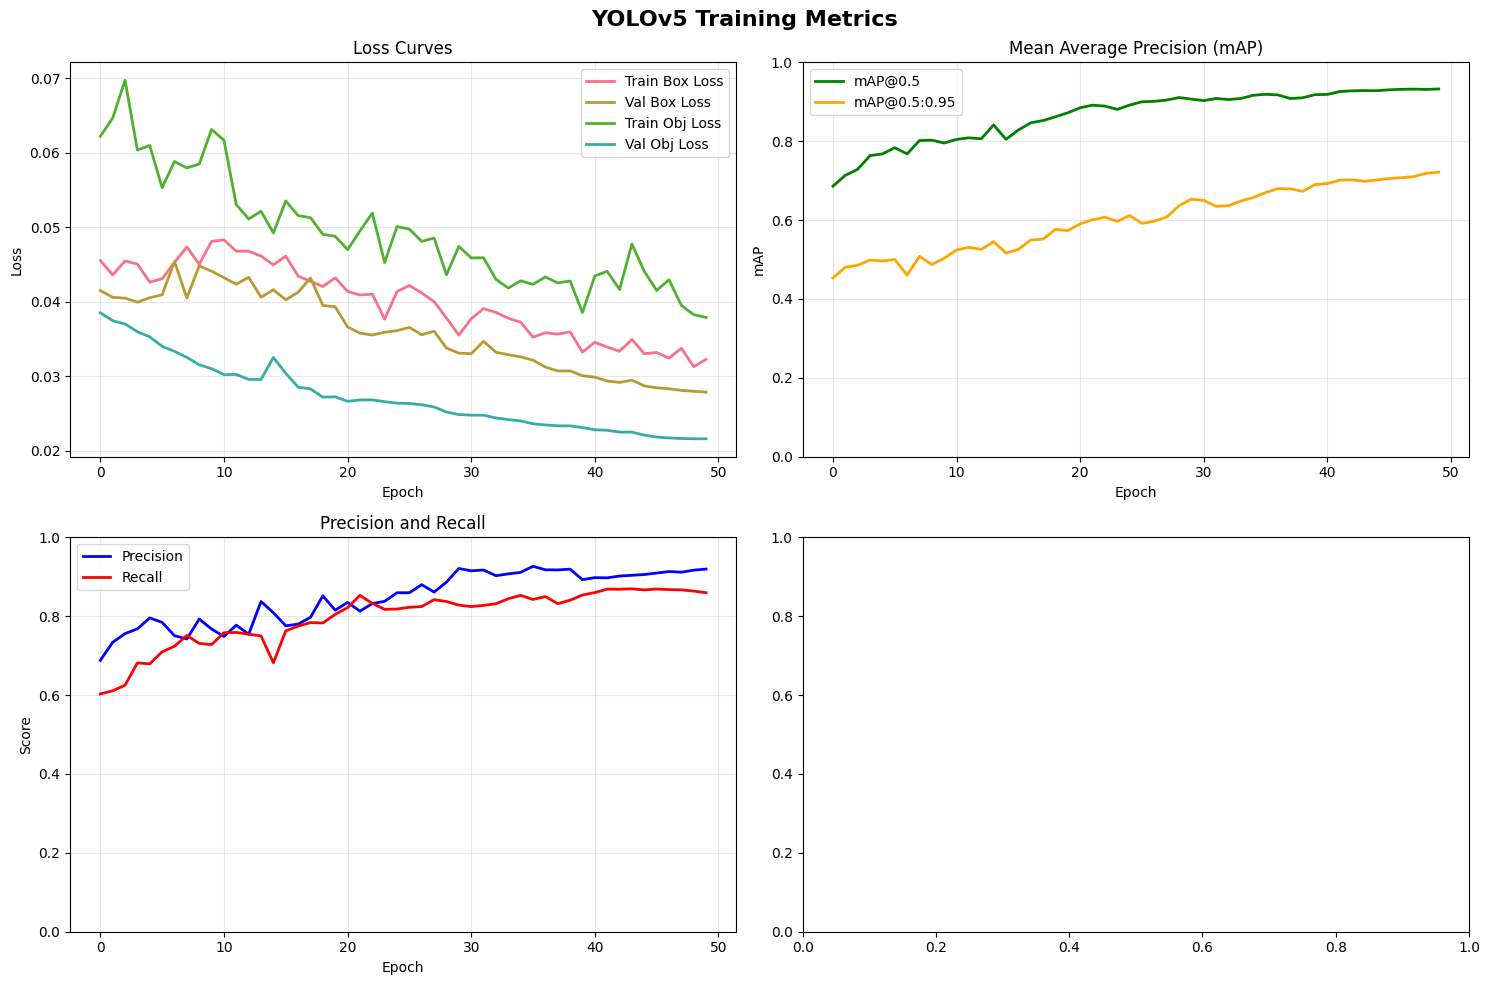


Final Training Metrics:
   • Final mAP@0.5: 0.9324
   • Final mAP@0.5:0.95: 0.7216
   • Final Precision: 0.9195
   • Final Recall: 0.8596

Confusion Matrix:


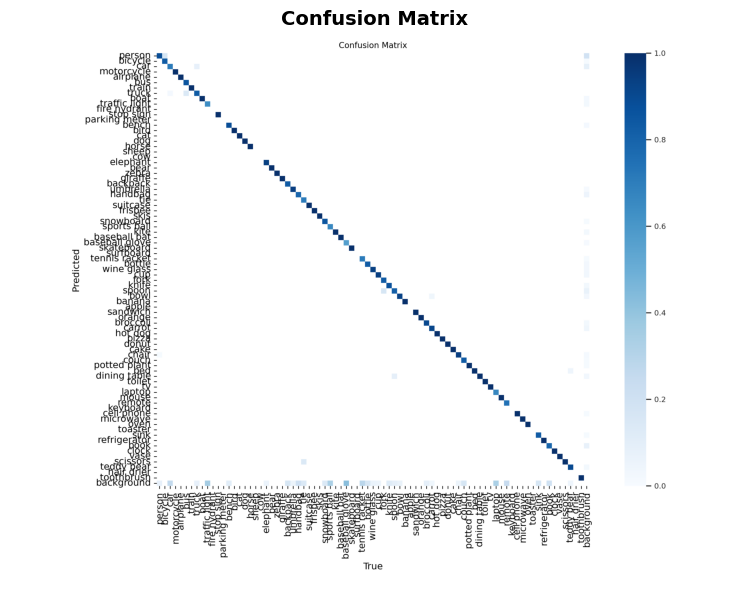


Training Results Overview:


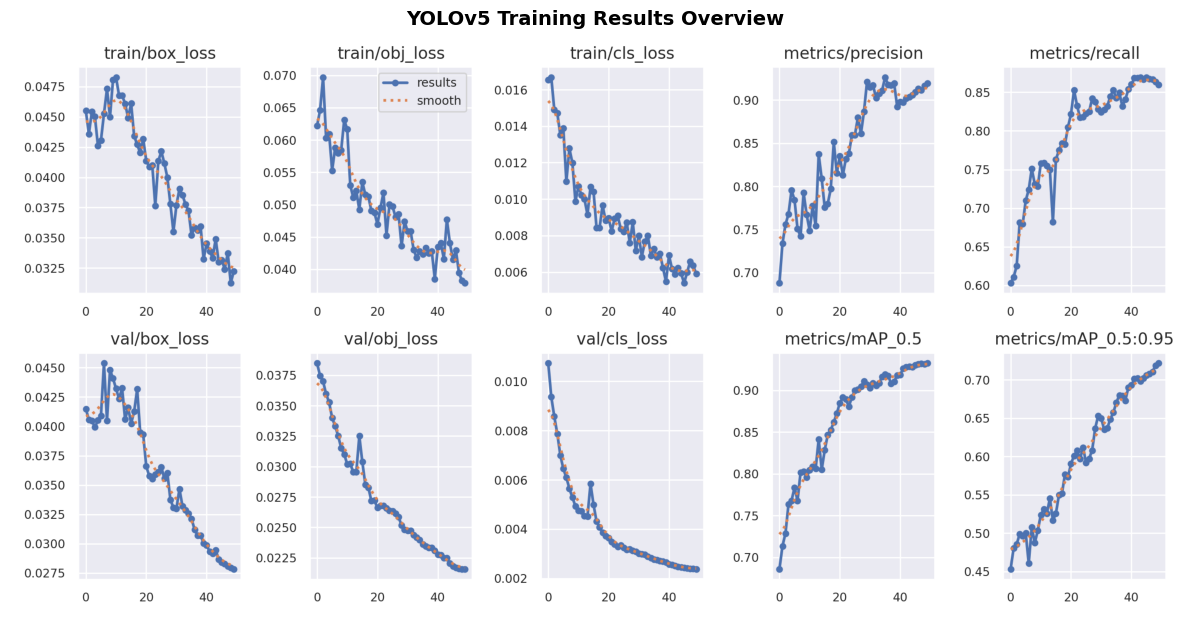


Validation Results:


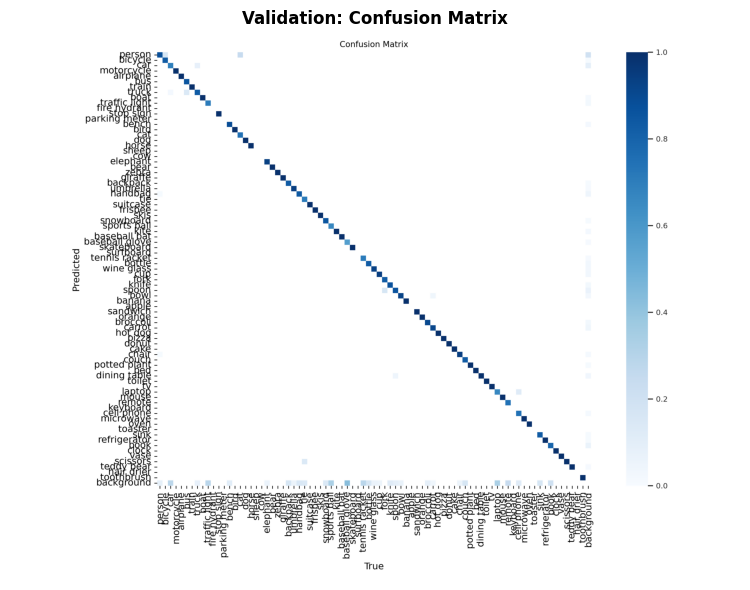

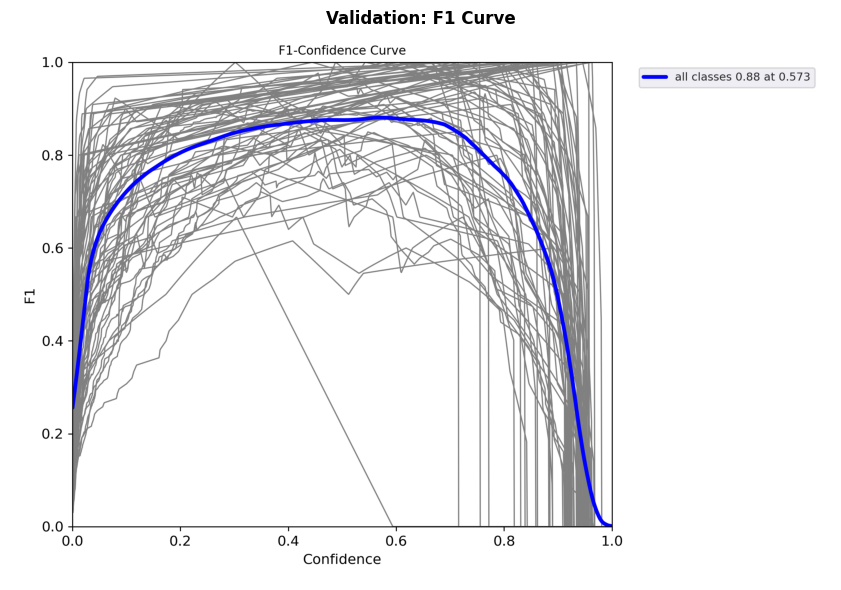

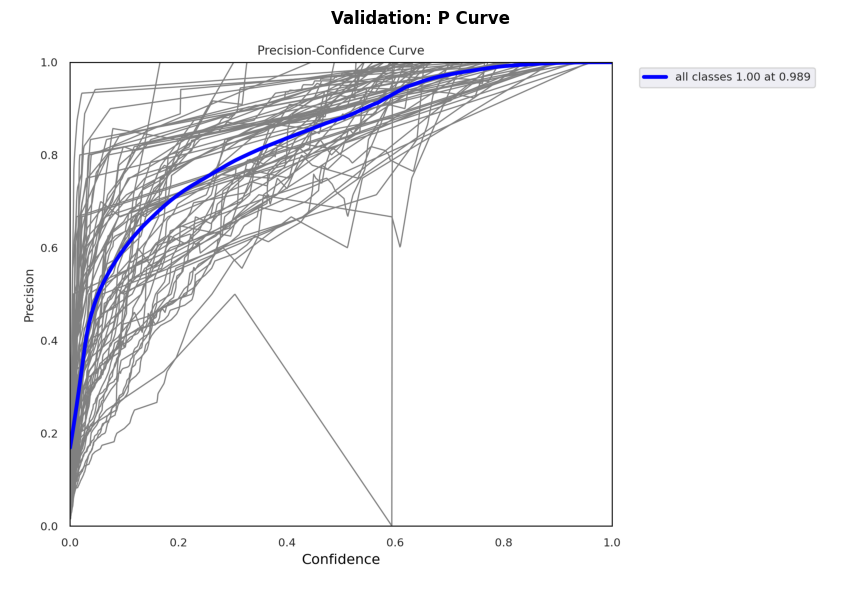

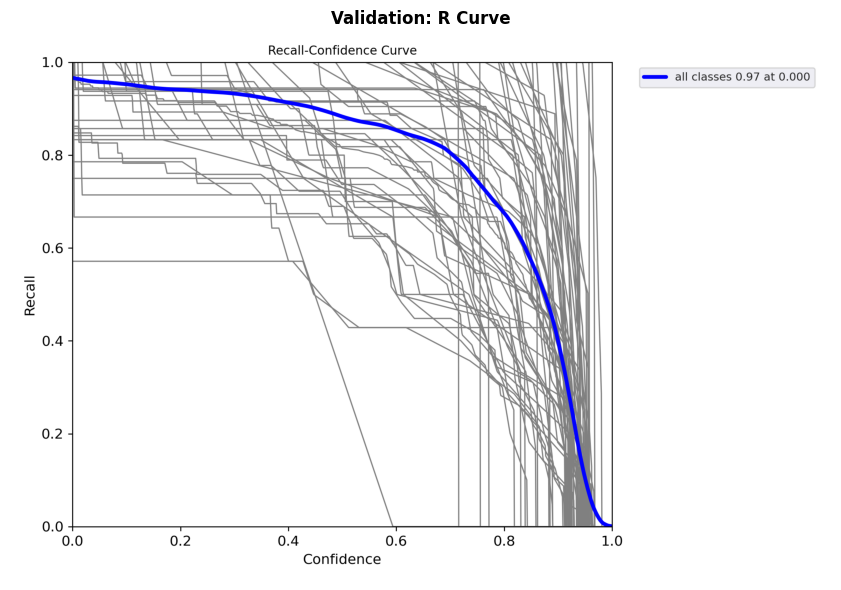

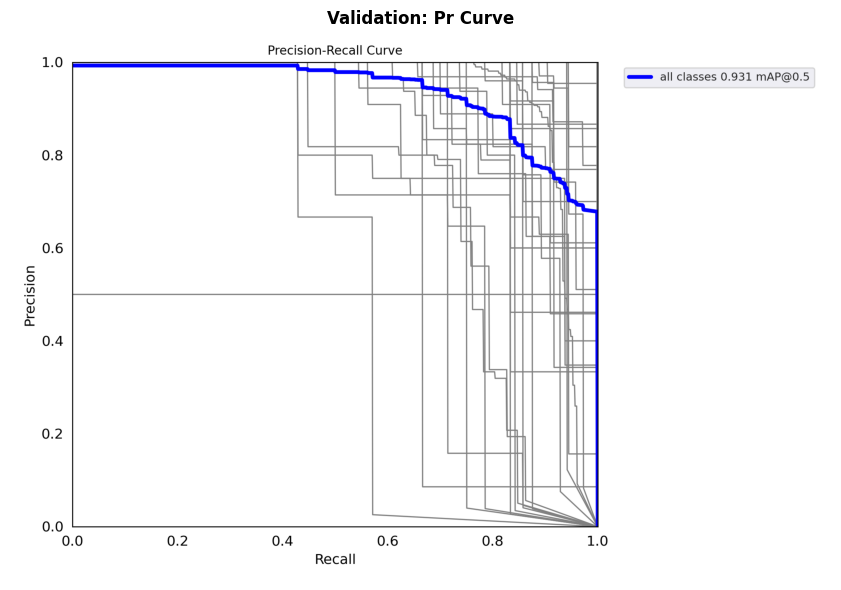


Sample Training Images with Predictions:


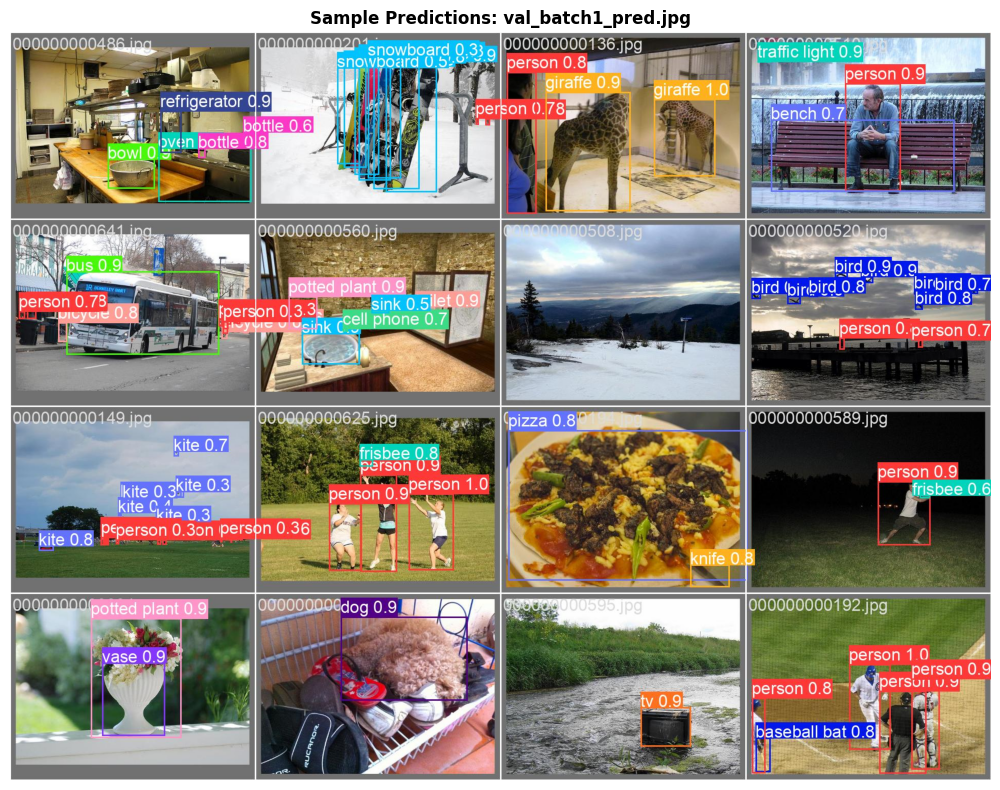

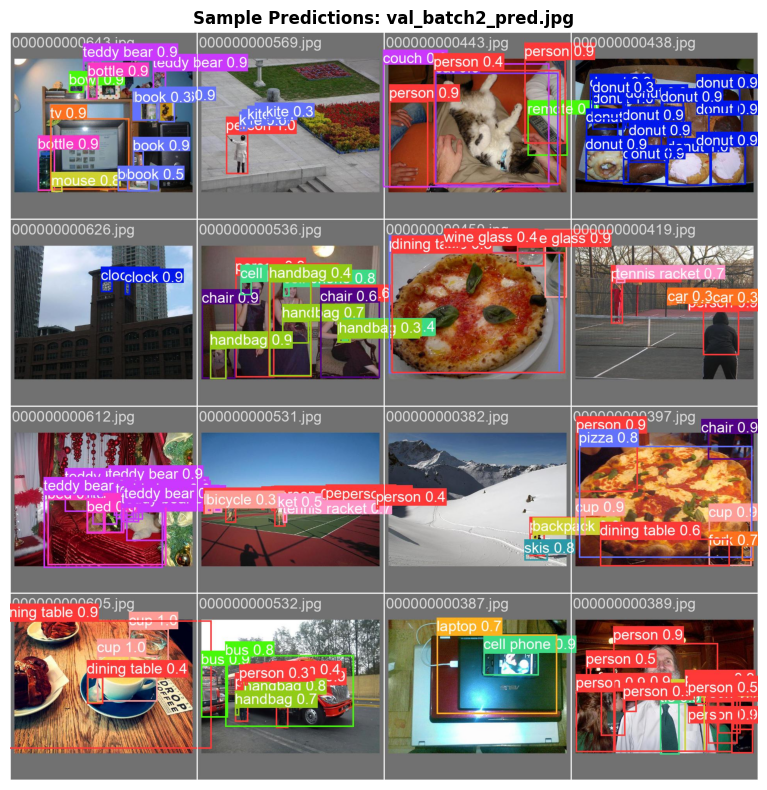

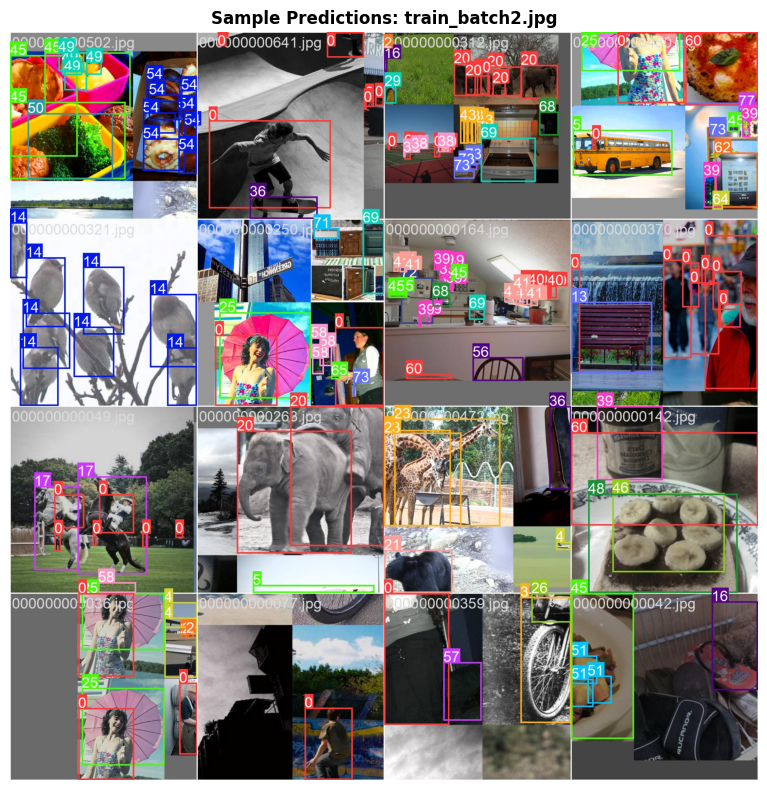


Training Progress Summary:


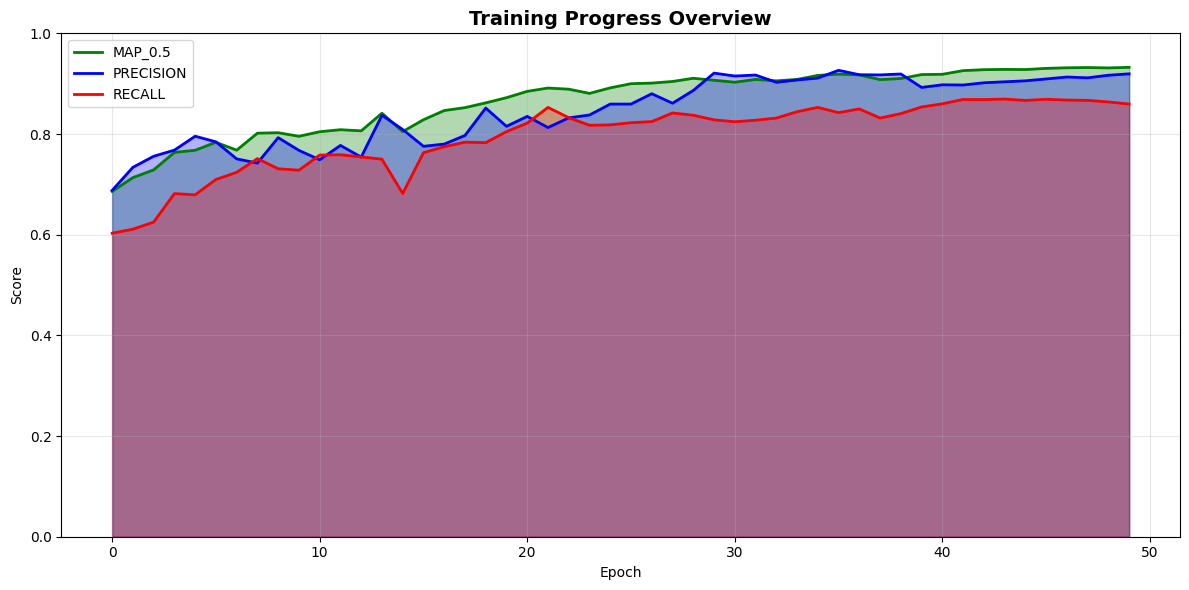

In [ ]:
# Display training results with inline visualizations if training was successful
if training_success:
    display_training_results()
else:
    print("Skipping visualizations - training was not successful")

# Optional - Test Model on Sample Images

In [ ]:
def test_model_inference():
    if not training_success or not best_weights:
        print("Cannot test model - training was not successful")
        return

    original_dir = os.getcwd()
    os.chdir('yolov5')

    # Test inference command
    detect_cmd = [
        sys.executable, 'detect.py',
        '--weights', f'../{best_weights}',
        '--source', '../Thesis/dataset/images/val',  # Use dataset images
        '--img', '640',
        '--conf', '0.25',
        '--project', '../Thesis/output',
        '--name', 'inference_results',
        '--save-txt',
        '--save-conf',
        '--max-det', '10'
    ]

    try:
        print("Running inference on sample images...")
        print(f"Command: {' '.join(detect_cmd)}")

        result = subprocess.run(detect_cmd, capture_output=True, text=True, timeout=300)

        if result.returncode == 0:
            print("Inference completed successfully")

            # Check output directory
            output_dir = "Thesis/output/inference_results"
            if os.path.exists(output_dir):
                output_files = os.listdir(output_dir)
                image_files = [f for f in output_files if f.lower().endswith(('.jpg', '.png'))]

                print(f"Generated {len(image_files)} result images")
                print(f"Results saved in: {os.path.abspath(output_dir)}")

                # List some result files
                for i, img_file in enumerate(image_files[:5]):
                    print(f"  - {img_file}")
                if len(image_files) > 5:
                    print(f"  ... and {len(image_files) - 5} more images")

        else:
            print("Inference failed")
            print("Error:", result.stderr)

    except subprocess.TimeoutExpired:
        print("Inference timed out after 5 minutes")
    except Exception as e:
        print(f"Inference failed with exception: {e}")
    finally:
        os.chdir(original_dir)

In [ ]:
# Run inference test
print("\nOptional: Testing Model Inference ###")
test_model_inference()


Optional: Testing Model Inference ###
Running inference on sample images...
Command: /usr/bin/python3 detect.py --weights ../Thesis/training_results/yolov5s_training/weights/best.pt --source ../Thesis/dataset/images/val --img 640 --conf 0.25 --project ../Thesis/output --name inference_results --save-txt --save-conf --max-det 10
Inference completed successfully


Download the files

In [ ]:
# Create zip of entire content folder
!zip -r /content/colab_content.zip /content/

# Download the zip
from google.colab import files
files.download('/content/colab_content.zip')

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/.last_update_check.json (deflated 22%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.09.09/ (stored 0%)
  adding: content/.config/logs/2025.09.09/13.46.08.280393.log (deflated 58%)
  adding: content/.config/logs/2025.09.09/13.45.20.812567.log (deflated 92%)
  adding: content/.config/logs/2025.09.09/13.46.02.456374.log (deflated 86%)
  adding: content/.config/logs/2025.09.09/13.46.20.727375.log (deflated 57%)
  adding: content/.config/logs/2025.09.09/13.46.21.527799.log (deflated 56%)
  adding: content/.config/logs/2025.09.09/13.45.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>